# Monitoramento de Modelos

Este notebook demonstra os dois endpoints implementados em `app/api/endpoints/performance.py` e `app/api/endpoints/aderencia.py`, chamando a API **rodando localmente**.

Antes de rodar este notebook, suba a API a partir da pasta `monitoring/`:

```bash
cd monitoring
.venv/Scripts/python.exe -m uvicorn app.main:app --port 8001
```

Ver [README.md](../README.md) para detalhes de setup do ambiente e das decisões técnicas.

In [ ]:
import json
import requests

BASE_URL = "http://127.0.0.1:8001/v1"


## 1. Performance e volumetria: `POST /v1/performance`

Usa a lista de registros de [`batch_records.json`](batch_records.json) como body. A resposta traz **(a)** a volumetria mensal (contagem de registros por mês, a partir de `REF_DATE`) e **(b)** a performance do `model.pkl`, medida como AUC-ROC das probabilidades preditas contra `TARGET`.

In [2]:
with open("batch_records.json", encoding="utf-8") as f:
    records = json.load(f)

resp = requests.post(f"{BASE_URL}/performance", json=records)
performance_result = resp.json()
print("status_code:", resp.status_code)
print(json.dumps(performance_result, indent=2, ensure_ascii=False))


status_code: 200
{
  "n_records": 500,
  "volumetria": {
    "2017-01": 58,
    "2017-02": 55,
    "2017-03": 62,
    "2017-04": 49,
    "2017-05": 67,
    "2017-06": 63,
    "2017-07": 74,
    "2017-08": 72
  },
  "auc_roc": 0.5751748251748252
}

## 2. Aderência: `POST /v1/aderencia`

Cada chamada informa o caminho de um dataset local. A API escora esse dataset e a base fixa de referência (`../datasets/credit_01/test.gz`) com o mesmo `model.pkl`, e calcula o teste de Kolmogorov-Smirnov (`scipy.stats.ks_2samp`) entre as duas distribuições de score.

**Expectativa**: `train.gz` deve ter KS baixo (próxima da base de Teste, mesmo período de coleta); `oot.gz` deve ter KS mais alto (período posterior, captura *drift*).

### 2.1 Base de Treino (`train.gz`)

In [3]:
resp = requests.post(
    f"{BASE_URL}/aderencia",
    json={"dataset_path": "../datasets/credit_01/train.gz"},
)
ks_train_result = resp.json()
print("status_code:", resp.status_code)
print(json.dumps(ks_train_result, indent=2, ensure_ascii=False))


status_code: 200
{
  "dataset_path": "../datasets/credit_01/train.gz",
  "reference_dataset_path": "C:\Users\55819\challenge-data-scientist\datasets\credit_01\test.gz",
  "n_records": 120750,
  "n_records_reference": 51751,
  "ks_statistic": 0.0019183285403152617,
  "ks_pvalue": 0.999315259526548,
  "score_mean": 0.7924503142579447,
  "score_mean_reference": 0.7923805226829322,
  "unknown_categories": {}
}

### 2.2 Base Out-of-Time (`oot.gz`)

In [4]:
resp = requests.post(
    f"{BASE_URL}/aderencia",
    json={"dataset_path": "../datasets/credit_01/oot.gz"},
)
ks_oot_result = resp.json()
print("status_code:", resp.status_code)
print(json.dumps(ks_oot_result, indent=2, ensure_ascii=False))


status_code: 200
{
  "dataset_path": "../datasets/credit_01/oot.gz",
  "reference_dataset_path": "C:\Users\55819\challenge-data-scientist\datasets\credit_01\test.gz",
  "n_records": 91965,
  "n_records_reference": 51751,
  "ks_statistic": 0.021736133923338036,
  "ks_pvalue": 5.0522344570608844e-14,
  "score_mean": 0.7956362963664461,
  "score_mean_reference": 0.7923805226829322,
  "unknown_categories": {
    "VAR121": 3
  }
}

## 3. Leitura dos resultados

| Base | KS | p-valor | Interpretação |
|---|---|---|---|
| `train.gz` | ~0.0019 | ~0.999 | Estatisticamente indistinguível da base de Teste, mesmo período de coleta, sem *drift*. |
| `oot.gz` | ~0.0217 | ~5e-14 | Diferença estatisticamente significante, a base Out-of-Time (meses subsequentes) mostra *drift* na distribuição de score em relação à Teste, como esperado. |

A chamada com `oot.gz` também retornou `unknown_categories: {"VAR121": 3}`. São 3 registros que trazem um valor categórico (`"MUITO PROXIMO"`) nunca visto no treino do modelo. Isso já é, por si só, um sinal de deriva (aderência de vocabulário categórico), e é o motivo pelo qual a API sanitiza essas categorias para `NaN` antes de escorar. Sem isso, o `OneHotEncoder` original quebraria com `handle_unknown="error"` (ver seção *Decisões técnicas* do README).

## 4. Análise visual

Dois gráficos simples, montados a partir dos mesmos resultados já retornados pela API acima (nenhuma chamada nova). O primeiro contextualiza o tamanho da amostra por mês usada no cálculo da AUC; o segundo compara visualmente o KS de `train.gz` e `oot.gz` contra a base de Teste.

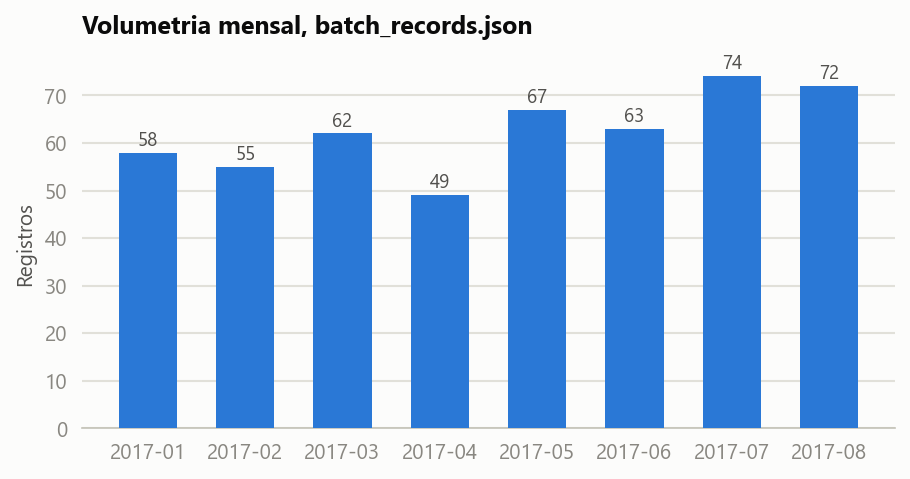

In [5]:
import matplotlib.pyplot as plt

BLUE = "#2a78d6"
GOOD = "#0ca30c"
CRITICAL = "#d03b3b"
PRIMARY_INK = "#0b0b0b"
SECONDARY_INK = "#52514e"
MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"

plt.rcParams.update({
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": SECONDARY_INK,
    "text.color": PRIMARY_INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "savefig.facecolor": "#fcfcfb",
})

meses = list(performance_result["volumetria"].keys())
valores = list(performance_result["volumetria"].values())

fig, ax = plt.subplots(figsize=(7, 3.2))
bars = ax.bar(meses, valores, color=BLUE, width=0.6, zorder=3)
ax.set_title("Volumetria mensal, batch_records.json", fontsize=12, fontweight="bold", loc="left", pad=12)
ax.set_ylabel("Registros")
ax.grid(axis="y", color=GRIDLINE, linewidth=1, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(BASELINE)
ax.tick_params(left=False, bottom=False)
for bar, v in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 1.5, str(v), ha="center", fontsize=9, color=SECONDARY_INK)
plt.show()


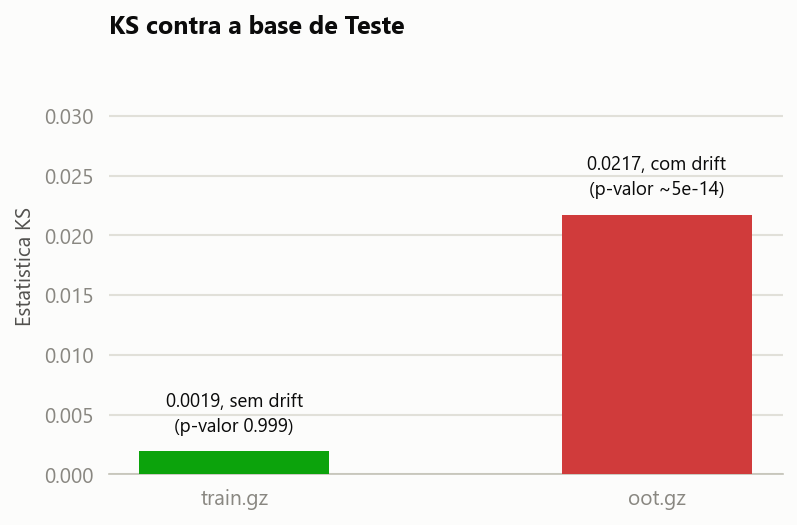

In [6]:
bases = ["train.gz", "oot.gz"]
ks_values = [ks_train_result["ks_statistic"], ks_oot_result["ks_statistic"]]
cores = [GOOD, CRITICAL]
top_labels = [
    f'{ks_values[0]:.4f}, sem drift
(p-valor {ks_train_result["ks_pvalue"]:.3f})',
    f'{ks_values[1]:.4f}, com drift
(p-valor {ks_oot_result["ks_pvalue"]:.1e})',
]

fig, ax = plt.subplots(figsize=(5.8, 3.6))
bars = ax.bar(bases, ks_values, color=cores, width=0.45, zorder=3)
ax.set_title("KS contra a base de Teste", fontsize=12, fontweight="bold", loc="left", pad=12)
ax.set_ylabel("Estatística KS")
ax.grid(axis="y", color=GRIDLINE, linewidth=1, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(BASELINE)
ax.tick_params(left=False, bottom=False, labelsize=10)
ax.set_ylim(0, max(ks_values) * 1.6)
for bar, label in zip(bars, top_labels):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(ks_values) * 0.06,
        label,
        ha="center", va="bottom", fontsize=9, color=PRIMARY_INK, linespacing=1.5,
    )
plt.show()


A diferença de escala entre as duas barras do segundo gráfico é o próprio resultado do teste: o KS de `oot.gz` é cerca de 11x maior que o de `train.gz`, e o p-valor caindo de 0.999 para ~5e-14 confirma que essa diferença não é ruído amostral. É o comportamento esperado de um modelo de crédito monitorado ao longo do tempo: a base mais distante do período de treino é onde a deriva aparece primeiro.